In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/rfm_modeling_snapshot.csv")

df.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [ ]:
df.shape

(2400, 29)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   snapshot_date             2400 non-null   object 
 2   city_tier                 2400 non-null   object 
 3   age_group                 2400 non-null   object 
 4   acquisition_channel       2400 non-null   object 
 5   loyalty_tier              1014 non-null   object 
 6   preferred_category        2400 non-null   object 
 7   marketing_consent         2400 non-null   object 
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
loyalty_tier,1386
snapshot_date,0
city_tier,0
age_group,0
customer_id,0
acquisition_channel,0
preferred_category,0
marketing_consent,0
recency_days,0
frequency_180d,0


In [ ]:
TARGET = "churn_next_60d"

In [ ]:
DROP_COLS = [
    "customer_id",
    "snapshot_date",
    "churn_next_60d"
]

In [ ]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

In [ ]:
X_train = train_df.drop(
    columns=DROP_COLS + ["split"]
)

y_train = train_df[TARGET]

In [ ]:
X_val = val_df.drop(
    columns=DROP_COLS + ["split"]
)

y_val = val_df[TARGET]

In [ ]:
X_test = test_df.drop(
    columns=DROP_COLS + ["split"]
)

y_test = test_df[TARGET]

In [ ]:
cat_cols = X_train.select_dtypes(
    include="object"
).columns.tolist()

num_cols = X_train.select_dtypes(
    exclude="object"
).columns.tolist()

cat_cols, num_cols

(['city_tier',
  'age_group',
  'acquisition_channel',
  'loyalty_tier',
  'preferred_category',
  'marketing_consent'],
 ['recency_days',
  'frequency_180d',
  'monetary_180d',
  'return_rate_180d',
  'avg_discount_pct_180d',
  'avg_rating_180d',
  'category_diversity_180d',
  'ticket_count_90d',
  'negative_ticket_rate_90d',
  'avg_resolution_hours_90d',
  'days_since_signup',
  'sessions_30d',
  'product_views_30d',
  'cart_adds_30d',
  'wishlist_adds_30d',
  'abandoned_carts_30d',
  'email_opens_30d',
  'campaign_clicks_30d',
  'last_visit_days_ago'])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [ ]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
baseline_model = Pipeline([
    ("prep", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

In [ ]:
baseline_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['recency_days',
                                                   'frequency_180d',
                                                   'monetary_180d',
                                                   'return_rate_180d',
                                                   'avg_discount_pct_180d',
                                                   'avg_rating_180d',
                                                   'category_diversity_180d',
                                                   'ticket_count_90d',
                                                   'negative_ticket_rate_90d',
                                                   'avg_resolution_hours_90d',
                                                   'days_since_sig...
                                                   'email_opens_30d',
                                                   'campaign_clicks_30d',
                                                   'last_visit_days_ago']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city_tier', 'age_group',
                                                   'acquisition_channel',
                                                   'loyalty_tier',
                                                   'preferred_category',
                                                   'marketing_consent'])])),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
val_probs = baseline_model.predict_proba(X_val)[:,1]

val_preds = (val_probs >= 0.5).astype(int)

In [ ]:
print("Accuracy:", accuracy_score(y_val, val_preds))
print("Precision:", precision_score(y_val, val_preds))
print("Recall:", recall_score(y_val, val_preds))
print("F1:", f1_score(y_val, val_preds))
print("ROC AUC:", roc_auc_score(y_val, val_probs))

Accuracy: 0.8154761904761905
Precision: 0.8102189781021898
Recall: 0.7551020408163265
F1: 0.7816901408450704
ROC AUC: 0.8837778497642444


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = Pipeline([
    ("prep", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=5,
            random_state=42
        )
    )
])

In [ ]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['recency_days',
                                                   'frequency_180d',
                                                   'monetary_180d',
                                                   'return_rate_180d',
                                                   'avg_discount_pct_180d',
                                                   'avg_rating_180d',
                                                   'category_diversity_180d',
                                                   'ticket_count_90d',
                                                   'negative_ticket_rate_90d',
                                                   'avg_resolution_hours_90d',
                                                   'days_since_sig...
                                                   'last_visit_days_ago']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city_tier', 'age_group',
                                                   'acquisition_channel',
                                                   'loyalty_tier',
                                                   'preferred_category',
                                                   'marketing_consent'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=5,
                                        n_estimators=300, random_state=42))])

In [ ]:
rf_probs = rf_model.predict_proba(X_val)[:,1]

rf_preds = (rf_probs >= 0.5).astype(int)

In [ ]:
print("Accuracy:", accuracy_score(y_val, rf_preds))
print("Precision:", precision_score(y_val, rf_preds))
print("Recall:", recall_score(y_val, rf_preds))
print("F1:", f1_score(y_val, rf_preds))
print("ROC AUC:", roc_auc_score(y_val, rf_probs))

Accuracy: 0.7976190476190477
Precision: 0.7969924812030075
Recall: 0.7210884353741497
F1: 0.7571428571428571
ROC AUC: 0.8806824317028399


In [ ]:
print("Full Dataset:", df.shape)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Full Dataset: (2400, 29)
Train: (1728, 29)
Validation: (336, 29)
Test: (336, 29)


In [ ]:
print("Train")
print(train_df['churn_next_60d'].value_counts(normalize=True))

print("\nValidation")
print(val_df['churn_next_60d'].value_counts(normalize=True))

print("\nTest")
print(test_df['churn_next_60d'].value_counts(normalize=True))

Train
churn_next_60d
0    0.530093
1    0.469907
Name: proportion, dtype: float64

Validation
churn_next_60d
0    0.5625
1    0.4375
Name: proportion, dtype: float64

Test
churn_next_60d
1    0.5
0    0.5
Name: proportion, dtype: float64


In [ ]:
print("Categorical Columns")
print(cat_cols)

print("\nNumber of categorical columns:", len(cat_cols))

print("\nNumerical Columns")
print(num_cols)

print("\nNumber of numerical columns:", len(num_cols))

Categorical Columns
['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent']

Number of categorical columns: 6

Numerical Columns
['recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']

Number of numerical columns: 19


In [ ]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds:

    preds = (val_probs >= threshold).astype(int)

    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        'threshold',
        'precision',
        'recall',
        'f1'
    ]
)

threshold_df.sort_values(
    'f1',
    ascending=False
).head(10)

,threshold,precision,recall,f1
7,0.45,0.790541,0.795918,0.793220
6,0.40,0.757764,0.829932,0.792208
5,0.35,0.725714,0.863946,0.788820
8,0.50,0.810219,0.755102,0.781690
4,0.30,0.686170,0.877551,0.770149
9,0.55,0.826772,0.714286,0.766423
3,0.25,0.648780,0.904762,0.755682
10,0.60,0.837607,0.666667,0.742424
11,0.65,0.849558,0.653061,0.738462
2,0.20,0.595652,0.931973,0.726790


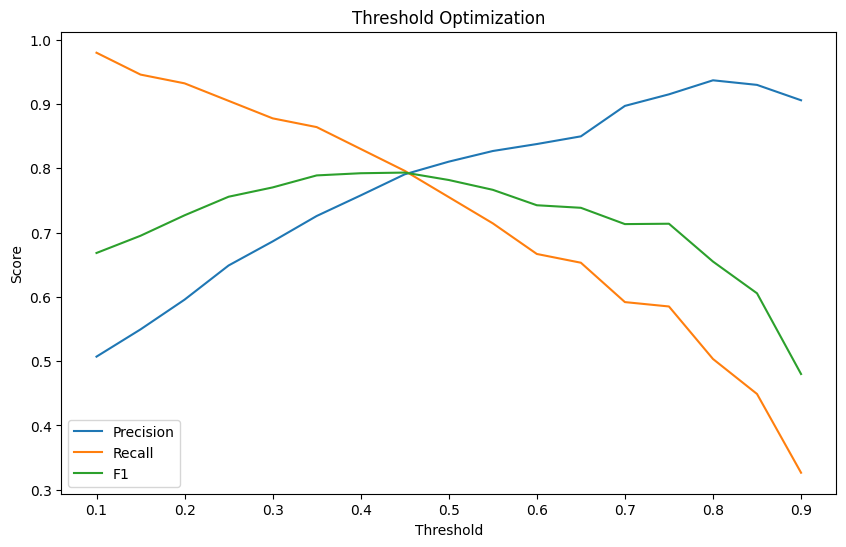

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df['threshold'],
    threshold_df['precision'],
    label='Precision'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['recall'],
    label='Recall'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['f1'],
    label='F1'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization')

plt.legend()
plt.show()

In [ ]:
threshold_df.sort_values(
    'f1',
    ascending=False
).head(10)

,threshold,precision,recall,f1
7,0.45,0.790541,0.795918,0.793220
6,0.40,0.757764,0.829932,0.792208
5,0.35,0.725714,0.863946,0.788820
8,0.50,0.810219,0.755102,0.781690
4,0.30,0.686170,0.877551,0.770149
9,0.55,0.826772,0.714286,0.766423
3,0.25,0.648780,0.904762,0.755682
10,0.60,0.837607,0.666667,0.742424
11,0.65,0.849558,0.653061,0.738462
2,0.20,0.595652,0.931973,0.726790


In [ ]:
FINAL_THRESHOLD = 0.45

final_val_preds = (
    val_probs >= FINAL_THRESHOLD
).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_val, final_val_preds))
print("Precision:", precision_score(y_val, final_val_preds))
print("Recall:", recall_score(y_val, final_val_preds))
print("F1:", f1_score(y_val, final_val_preds))
print("ROC AUC:", roc_auc_score(y_val, val_probs))

print("\nConfusion Matrix")
print(confusion_matrix(y_val, final_val_preds))

Accuracy: 0.8184523809523809
Precision: 0.7905405405405406
Recall: 0.7959183673469388
F1: 0.7932203389830509
ROC AUC: 0.8837778497642444

Confusion Matrix
[[158  31]
 [ 30 117]]


In [ ]:
test_probs = baseline_model.predict_proba(X_test)[:,1]

test_preds = (
    test_probs >= FINAL_THRESHOLD
).astype(int)

In [ ]:
feature_names = (
    baseline_model.named_steps['prep']
    .get_feature_names_out()
)

coefficients = (
    baseline_model.named_steps['model']
    .coef_[0]
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

importance_df['abs_coef'] = (
    importance_df['coefficient'].abs()
)

importance_df.sort_values(
    'abs_coef',
    ascending=False
).head(20)

,feature,coefficient,abs_coef
3,num__return_rate_180d,1.465790,1.465790
8,num__negative_ticket_rate_90d,0.842390,0.842390
4,num__avg_discount_pct_180d,0.813990,0.813990
7,num__ticket_count_90d,-0.514593,0.514593
36,cat__preferred_category_Fragrance,-0.457342,0.457342
30,cat__acquisition_channel_Organic,-0.433610,0.433610
33,cat__loyalty_tier_Platinum,-0.398413,0.398413
42,cat__marketing_consent_Yes,-0.320128,0.320128
17,num__campaign_clicks_30d,-0.204293,0.204293
37,cat__preferred_category_Hair Care,-0.187710,0.187710


In [ ]:
import joblib

joblib.dump(
    baseline_model,
    "model.pkl"
)

['model.pkl']

In [ ]:
error_analysis = val_df.copy()

error_analysis['actual'] = y_val.values
error_analysis['predicted'] = final_val_preds
error_analysis['probability'] = val_probs

In [ ]:
false_positives = error_analysis[
    (error_analysis['actual'] == 0) &
    (error_analysis['predicted'] == 1)
]

false_positives[[
    'customer_id',
    'probability',
    'recency_days',
    'frequency_180d',
    'monetary_180d'
]].head(5)

,customer_id,probability,recency_days,frequency_180d,monetary_180d
26,CUST00027,0.485639,70,1,2128.34
99,CUST00100,0.668936,70,1,372.37
143,CUST00144,0.592868,86,2,928.58
164,CUST00165,0.509945,103,3,1825.77
176,CUST00177,0.737637,82,1,255.04


In [ ]:
false_negatives = error_analysis[
    (error_analysis['actual'] == 1) &
    (error_analysis['predicted'] == 0)
]

false_negatives[[
    'customer_id',
    'probability',
    'recency_days',
    'frequency_180d',
    'monetary_180d'
]].head(5)

,customer_id,probability,recency_days,frequency_180d,monetary_180d
92,CUST00093,0.266588,85,1,759.64
144,CUST00145,0.410163,30,1,502.35
156,CUST00157,0.213594,0,1,376.83
187,CUST00188,0.112131,29,2,1880.31
266,CUST00267,0.107604,29,1,441.97


In [ ]:
import json

metrics = {
    "model": "Logistic Regression",
    "threshold": 0.45,
    "accuracy": 0.8185,
    "precision": 0.7905,
    "recall": 0.7959,
    "f1_score": 0.7932,
    "roc_auc": 0.8838
}

with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

In [ ]:
test_probs = baseline_model.predict_proba(X_test)[:,1]

test_preds = (
    test_probs >= FINAL_THRESHOLD
).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds))
print("Recall:", recall_score(y_test, test_preds))
print("F1:", f1_score(y_test, test_preds))
print("ROC AUC:", roc_auc_score(y_test, test_probs))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, test_preds))

Accuracy: 0.8095238095238095
Precision: 0.7954545454545454
Recall: 0.8333333333333334
F1: 0.813953488372093
ROC AUC: 0.8858418367346941

Confusion Matrix
[[132  36]
 [ 28 140]]


# Model Comparison

Two machine learning models were evaluated for churn prediction:

1. Logistic Regression
2. Random Forest

The objective was to identify the model that provided the strongest predictive performance while maintaining business interpretability.

The models were compared using the validation dataset before threshold optimization.

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.8155, 0.7976],
    "Precision": [0.8102, 0.7970],
    "Recall": [0.7551, 0.7211],
    "F1 Score": [0.7817, 0.7571],
    "ROC-AUC": [0.8838, 0.8807]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8155,0.8102,0.7551,0.7817,0.8838
1,Random Forest,0.7976,0.7970,0.7211,0.7571,0.8807
